In [112]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [114]:
df = pd.read_csv("../files/processed/dataco_supply_chain.csv")
df.sample(5)

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,customer_id,customer_lname,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,order_city,order_country,order_customer_id,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_status,product_card_id,product_category_id,product_name,product_price,shipping_mode,delivery_date,order_date,order_time
26412,DEBIT,2,1,4.22,48.00,Late delivery,1,24,Women's Apparel,Caguas,Puerto Rico,Emma,7479,Smith,Corporate,Puerto Rico,4806 Dusty Bear Avenue,725,5,Golf,Klagenfurt,Austria,7479,42378,502,2.00,0.04,105818,50.00,0.09,1,50.00,48.00,4.22,Western Europe,COMPLETE,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.00,First Class,09-12-2016,09-10-2016,14:33
160830,TRANSFER,4,4,-5.12,20.49,Shipping on time,0,5,Lacrosse,Caguas,Puerto Rico,Thomas,8869,Lambert,Consumer,Puerto Rico,2777 Crystal Blossom Dale,725,2,Fitness,San Francisco,Estados Unidos,8869,38803,93,4.50,0.18,96888,24.99,-0.25,1,24.99,20.49,-5.12,West of USA,PROCESSING,93,5,Under Armour Men's Tech II T-Shirt,24.99,Standard Class,07-24-2016,07-20-2016,10:04
120374,TRANSFER,3,4,19.53,55.79,Advance shipping,0,17,Cleats,Augusta,EE. UU.,Patrick,9989,Parsons,Consumer,Georgia,3247 Shady Timber Loop,30906,4,Apparel,London,Reino Unido,9989,19442,365,4.20,0.07,48586,59.99,0.35,1,59.99,55.79,19.53,Northern Europe,PENDING,365,17,Perfect Fitness Perfect Rip Deck,59.99,Standard Class,10-14-2015,10-11-2015,19:02
127664,PAYMENT,3,4,62.67,172.66,Advance shipping,0,76,Women's Clothing,Caguas,Puerto Rico,Guinevere,20610,Butler,Consumer,Puerto Rico,7358 Gentle Manor,725,4,Apparel,Orange,Australia,20610,77057,1363,43.16,0.20,180372,215.82,0.36,1,215.82,172.66,62.67,Oceania,PENDING_PAYMENT,1363,76,Summer dresses,215.82,Standard Class,02-01-2018,01-29-2018,20:08
73886,DEBIT,3,4,65.34,179.99,Advance shipping,0,48,Water Sports,Seattle,EE. UU.,Mary,7499,Powell,Consumer,Washington,325 Bright Centre,98115,7,Fan Shop,Timisoara,Rumania,7499,45972,1073,20.00,0.10,114888,199.99,0.36,1,199.99,179.99,65.34,Eastern Europe,COMPLETE,1073,48,Pelican Sunstream 100 Kayak,199.99,Standard Class,11-05-2016,11-02-2016,01:41


## Comparativa de pedidos que llegan o no a tiempo

In [115]:
df["late_delivery_risk"] = df["late_delivery_risk"].map({0: "No", 1: "Sí"})

In [116]:
conteo = df["late_delivery_risk"].value_counts()

In [117]:
colores = ['#2b7b97', '#e2c58a']

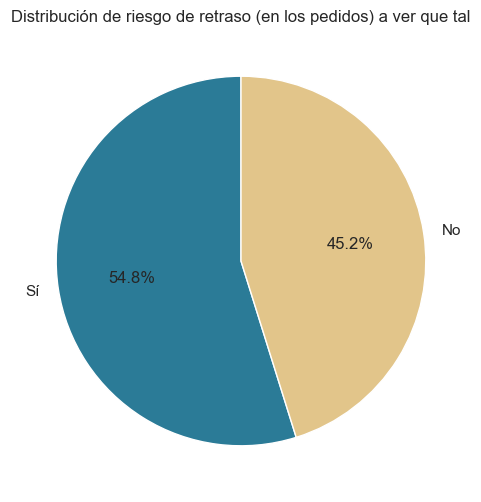

In [118]:
plt.figure(figsize=(6,6))
plt.pie(
    conteo.values,
    labels=conteo.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colores
)
plt.title("Distribución de riesgo de retraso (en los pedidos) a ver que tal")
plt.show()

### mas de la mitad de los pedidos no cumplen con la fecha acordado de entrega

## Estados en lo que se retrasan más los pedidos

In [119]:
# 1. Filtrar retrasos
df_late = df[df["late_delivery_risk"] == "Sí"]
 
# 2. Obtener los 10 estados con más retrasos
top10_estados = (df_late["order_country"].value_counts().head(10).sort_values(ascending=False))
 

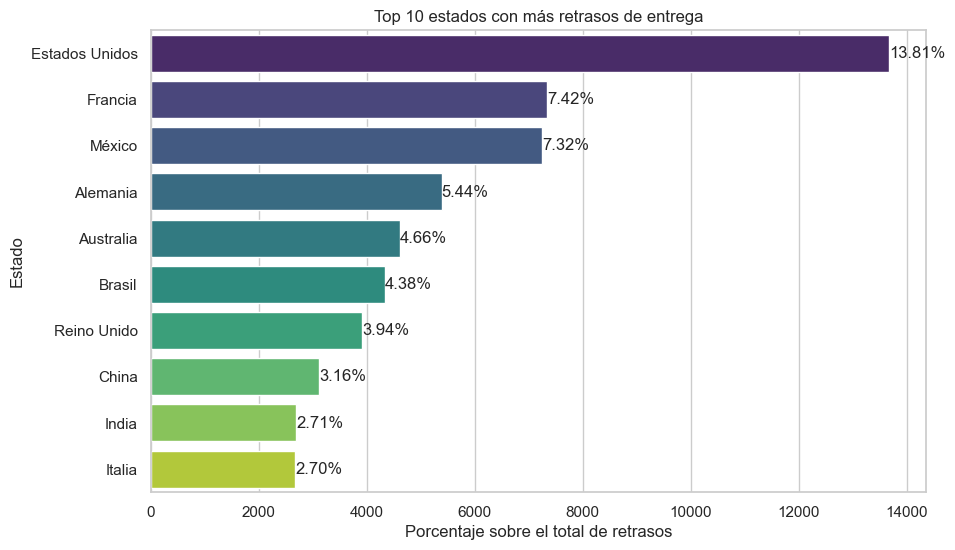

In [120]:
plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=df_late[df_late["order_country"].isin(top10_estados.index)],
    y="order_country",
    order=top10_estados.index,
    palette="viridis"
)
 
# Total de retrasos
total_retrasos = len(df_late)
 
# Añadir porcentaje al final de cada barra
for p in ax.patches:
    ancho = p.get_width()  # valor de la barra
    y = p.get_y() + p.get_height() / 2
    porcentaje = (ancho / total_retrasos) * 100
 
    ax.text(
        ancho + 5,
        y,
        f"{porcentaje:.2f}%",
        va="center"
    )
 
plt.title("Top 10 estados con más retrasos de entrega")
plt.xlabel("Porcentaje sobre el total de retrasos")
plt.ylabel("Estado")
plt.show()

## Estado de los pedidos según entrega

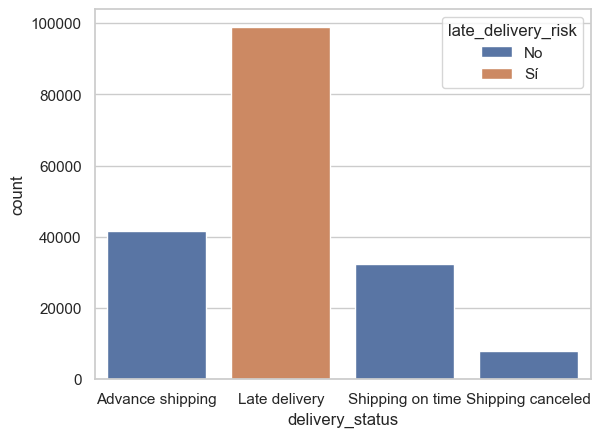

In [121]:
sns.countplot(data=df, x="delivery_status", hue="late_delivery_risk");

## Exploramos si existia relación entre delivery_status y order_status

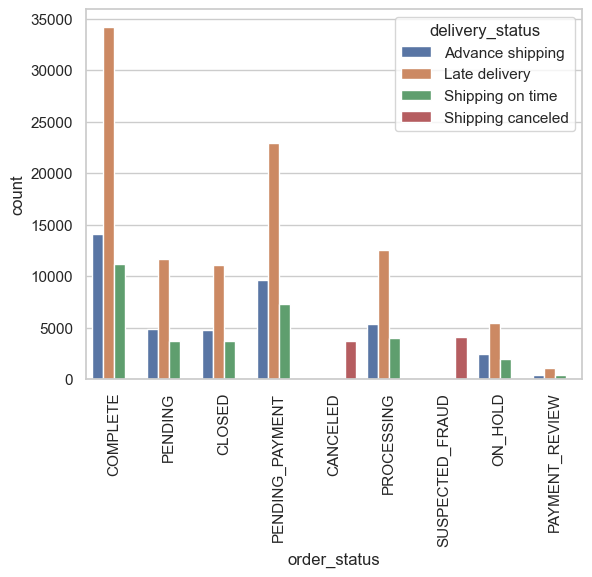

In [122]:
sns.countplot(data=df, x="order_status", hue="delivery_status")
plt.xticks(rotation= 90);

In [ ]:
## Observamos que los datos al ser sintéticos no tienen coherencia

## Relación entre el estado del pedido y el beneficio

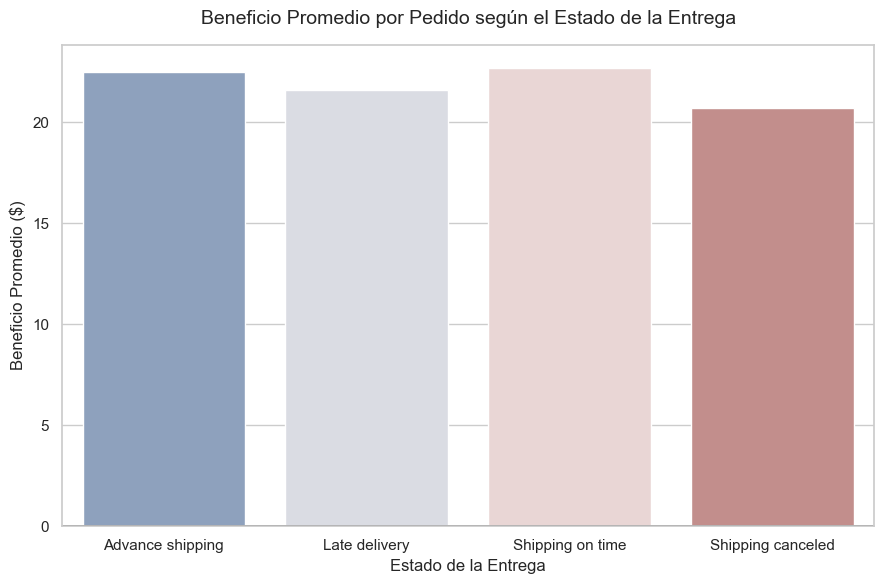

In [124]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
 
# Graficamos el beneficio promedio según el estado de la entrega
sns.barplot(
    data=df,
    x="delivery_status",
    y="order_profit_per_order",
    palette="vlag",
    errorbar=None # Elimina las barras de error para limpiar el gráfico
)
 
# Añadir una línea en el 0 para identificar visualmente las pérdidas operativas
plt.axhline(0, color='black', linestyle='-', linewidth=1.2)
 
plt.title("Beneficio Promedio por Pedido según el Estado de la Entrega", fontsize=14, pad=15)
plt.xlabel("Estado de la Entrega")
plt.ylabel("Beneficio Promedio ($)")
plt.tight_layout()
plt.show()

In [ ]:
# Observamos una vez mas que debido a la inconsistencia de los datos, la respuesta no es aceptable

In [ ]:

 
# =====================================================================
# 1. MÉTRICAS GENERALES DE LA EMPRESA (Línea Base)
# =====================================================================
ganancia_total_empresa = df['order_profit_per_order'].sum()
ventas_totales_empresa = df['sales'].sum()
 
# Pedidos eficientes (Cuando NO hay retraso, es decir, diferente de "Sí")
df_eficientes = df[df['late_delivery_risk'] != "Sí"]
ganancia_pedidos_a_tiempo = df_eficientes['order_profit_per_order'].sum()
 
 
# =====================================================================
# 2. MÉTRICAS DE IMPACTO POR RETRASOS (Filtro exacto por "Sí")
# =====================================================================
df_retrasados = df[df['late_delivery_risk'] == "Sí"]
 
# Pérdidas directas (Beneficios negativos en órdenes retrasadas)
perdidas_directas_retrasos = df_retrasados[df_retrasados['order_profit_per_order'] < 0]['order_profit_per_order'].sum()
# Convertimos a positivo para el reporte visual
perdidas_puras = abs(perdidas_directas_retrasos)
 
# Beneficio atrapado en pedidos retrasados (Margen en riesgo)
beneficio_en_riesgo = df_retrasados['order_profit_per_order'].sum()
ventas_afectadas = df_retrasados['sales'].sum()
 
 
# =====================================================================
# 3. ANÁLISIS DE PROPORCIÓN (KPIs de Negocio)
# =====================================================================
# ¿Cuánto representan las pérdidas directas sobre la ganancia total?
porcentaje_perdida = (perdidas_puras / ganancia_total_empresa) * 100 if ganancia_total_empresa > 0 else 0
 
# ¿Qué porcentaje del dinero total de la empresa se vio afectado por retrasos?
porcentaje_ventas_afectadas = (ventas_afectadas / ventas_totales_empresa) * 100
 
 
# =====================================================================
# 4. BALANCE GENERAL EN CONSOLA
# =====================================================================
print(f"================================================================")
print(f"                BALANCE FINANCIERO DE LA OPERACIÓN               ")
print(f"================================================================")
print(f"(+) Ventas Totales Históricas:             ${ventas_totales_empresa:,.2f}")
print(f"(+) Ganancia Neta Total de la Empresa:      ${ganancia_total_empresa:,.2f}")
print(f"    └─ Ganancia por pedidos A Tiempo:       ${ganancia_pedidos_a_tiempo:,.2f}")
print(f"----------------------------------------------------------------")
print(f"               EL IMPACTO DE LOS RETRASOS (LOGÍSTICA)           ")
print(f"----------------------------------------------------------------")
print(f"(-) Pérdidas Directas por Retrasos:        ${perdidas_puras:,.2f}") 
print(f"    └─ Impacto en la ganancia neta:        {porcentaje_perdida:.2f}% del total")
print(f"")
print(f"(!) Margen Neto en Riesgo (Llegó tarde):    ${beneficio_en_riesgo:,.2f}")
print(f"(!) Volumen de Ventas Afectado:            ${ventas_afectadas:,.2f}")
print(f"    └─ Exposición al riesgo cliente:       {porcentaje_ventas_afectadas:.2f}% de las ventas")
print(f"================================================================")

                BALANCE FINANCIERO DE LA OPERACIÓN               
(+) Ventas Totales Históricas:             $36,784,734.31
(+) Ganancia Neta Total de la Empresa:      $3,966,902.97
    └─ Ganancia por pedidos A Tiempo:       $1,826,851.29
----------------------------------------------------------------
               EL IMPACTO DE LOS RETRASOS (LOGÍSTICA)           
----------------------------------------------------------------
(-) Pérdidas Directas por Retrasos:        $2,153,626.61
    └─ Impacto en la ganancia neta:        54.29% del total

(!) Margen Neto en Riesgo (Llegó tarde):    $2,140,051.68
(!) Volumen de Ventas Afectado:            $20,126,394.88
    └─ Exposición al riesgo cliente:       54.71% de las ventas


In [ ]:
# Intentamos de otra manera demostrar la relacion entre estado de pedido y beneficios, nuevamente vemos que el resultado no es lógico

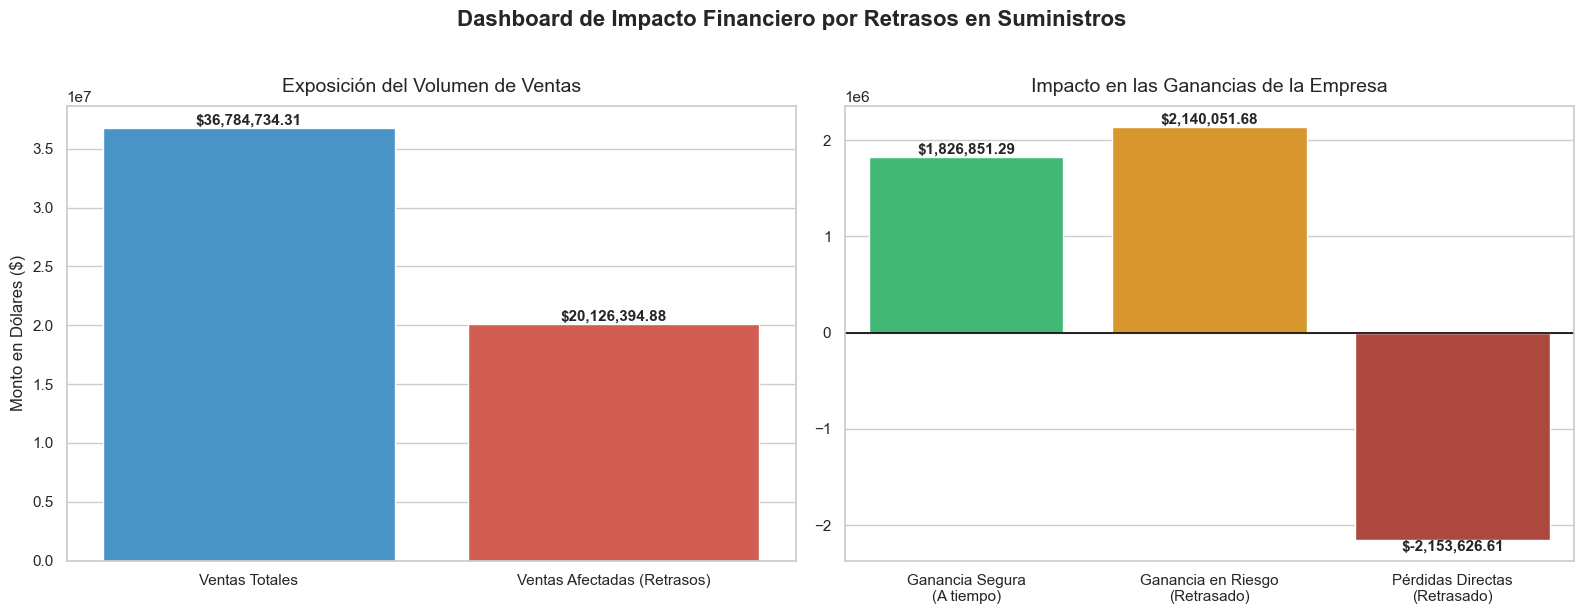

In [126]:
# 1. Configurar el lienzo para dos gráficas preparadas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")
 
# =====================================================================
# GRÁFICA 1: VENTAS TOTALES VS. VENTAS AFECTADAS POR RETRASOS
# =====================================================================
datos_ventas = {
    'Métrica': ['Ventas Totales', 'Ventas Afectadas (Retrasos)'],
    'Monto': [ventas_totales_empresa, ventas_afectadas]
}
df_ventas_graf = pd.DataFrame(datos_ventas)
 
sns.barplot(
    data=df_ventas_graf, 
    x='Métrica', 
    y='Monto', 
    ax=axes[0], 
    palette=['#3498db', '#e74c3c'] # Azul para el total, Rojo para el riesgo
)
 
axes[0].set_title("Exposición del Volumen de Ventas", fontsize=14, pad=10)
axes[0].set_ylabel("Monto en Dólares ($)")
axes[0].set_xlabel("")
 
# Añadir etiquetas de texto sobre las barras
for bar in axes[0].patches:
    axes[0].annotate(
        f"${bar.get_height():,.2f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

    # GRÁFICA 2: DESTINO DE LAS GANANCIAS (A tiempo, En Riesgo, Pérdidas)
# =====================================================================
datos_ganancias = {
    'Estado del Margen': ['Ganancia Segura\n(A tiempo)', 'Ganancia en Riesgo\n(Retrasado)', 'Pérdidas Directas\n(Retrasado)'],
    'Monto': [ganancia_pedidos_a_tiempo, beneficio_en_riesgo, -perdidas_puras] # Pérdidas en negativo para el impacto visual
}
df_ganancias_graf = pd.DataFrame(datos_ganancias)
 
sns.barplot(
    data=df_ganancias_graf, 
    x='Estado del Margen', 
    y='Monto', 
    ax=axes[1], 
    palette=['#2ecc71', '#f39c12', '#c0392b'] # Verde (Seguro), Amarillo (Riesgo), Rojo Oscuro (Pérdida)
)
 
# Línea de referencia en 0 para marcar el umbral de pérdida operativa
axes[1].axhline(0, color='black', linestyle='-', linewidth=1.2)
 
axes[1].set_title("Impacto en las Ganancias de la Empresa", fontsize=14, pad=10)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
 
# Añadir etiquetas de texto sobre/bajo las barras
for bar in axes[1].patches:
    altura = bar.get_height()
    va_pos = 'bottom' if altura >= 0 else 'top' # Si es negativo, pone el texto abajo de la barra
    axes[1].annotate(
        f"${altura:,.2f}",
        (bar.get_x() + bar.get_width() / 2, altura),
        ha='center', va=va_pos, fontsize=11, fontweight='bold'
    )
 
# Ajustes finales de la presentación
plt.suptitle("Dashboard de Impacto Financiero por Retrasos en Suministros", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#Ayudadas por la IA en terminal intentamos de otra forma, con una visualización demostrar la relación entre los retrasos y el beneficio por producto.
#Nos damos cuenta de que al ser un Dataset pensado para la docencia no tienen relacion las columnas entre si 